# Analytical 3D elasticity


## Setting

### For parallel testing 

Create a serveur controlling  n>1 mpi engines
(consider openmpi as mpi backend)

In [1]:
#nopy
import ipyparallel as ipp
cluster = ipp.Cluster(engines="mpi", n=2)
rc = cluster.start_and_connect_sync()
view=rc[:]

Starting 8 engines with <class 'ipyparallel.cluster.launcher.MPIEngineSetLauncher'>


  0%|          | 0/8 [00:00<?, ?engine/s]

In [2]:
%pxconfig --progress-after -1

In [3]:
%%px
from dolfinx import cpp
from dolfinx import log
from dolfinx import mesh
from dolfinx import fem
from dolfinx import plot
from dolfinx import io
import ufl
import petsc4py
from dolfinx.fem import petsc
import numpy as np
from mpi4py import MPI
from mpi4py.typing import InPlace

import pyvista as pv
import basix
from importlib import reload, import_module
from dolfinx_mpc import MultiPointConstraint
from dolfinx_mpc import LinearProblem as LinearProblem_mpc



In [ ]:
from dolfinx import (__version__,git_commit_hash)
print(f"DOLFINx version: {__version__} based on GIT commit: {git_commit_hash}")

### Import twosacle library

In [4]:
%%px
import sys
sys.dont_write_bytecode = True

In [5]:
%%px
from twoscale import core
from twoscale import linear
from twoscale import util

[stdout:4] Use Twoscale dolfinx implementation
Use Twoscale dolfinx implementation


[stdout:5] Use Twoscale dolfinx implementation
Use Twoscale dolfinx implementation


[stdout:3] Use Twoscale dolfinx implementation
Use Twoscale dolfinx implementation


[stdout:1] Use Twoscale dolfinx implementation
Use Twoscale dolfinx implementation


[stdout:6] Use Twoscale dolfinx implementation
Use Twoscale dolfinx implementation


[stdout:7] Use Twoscale dolfinx implementation
Use Twoscale dolfinx implementation


[stdout:0] Use Twoscale dolfinx implementation
Use Twoscale dolfinx implementation


[stdout:2] Use Twoscale dolfinx implementation
Use Twoscale dolfinx implementation


### Configuration


In [6]:
%%px
ref=3
itmax=30
epsr=1.e-7
with_plate0=True
show_petsc_log=False
show_fenicsx_log=False
petsc_options={"ksp_type":"cg","ksp_rtol":"1e-12","pc_type":"hypre","pc_hypre_type":"boomeramg","pc_hypre_type":"boomeramg","pc_hypre_boomeramg_coarsen_type":"HMIS","pc_hypre_boomeramg_relax_type_up":"l1scaled-SOR/Jacobi","pc_hypre_boomeramg_relax_type_down": "l1scaled-SOR/Jacobi","pc_hypre_boomeramg_relax_type_coarse":"Gaussian-elimination","pc_hypre_boomeramg_interp_type": "ext+i","pc_hypre_boomeramg_numfunctions": "2","pc_hypre_boomeramg_agg_nl": "0","pc_hypre_boomeramg_strong_threshold": "0.25","pc_hypre_boomeramg_print_statistics":"1"}
#petsc_options={"ksp_type":"preonly","pc_type":"lu","pc_factor_mat_solver_type":"mumps"}


In [7]:
%%px
if (show_petsc_log):
    petsc4py.PETSc.Log.begin()


In [8]:
%%px
if (show_fenicsx_log):
    log.set_log_level(cpp.log.LogLevel.INFO)


In [9]:
%%px
pvopt={"show_edges":True, "show_scalar_bar":True}

In [10]:
%%px
#nopy
pv.set_jupyter_backend("static")

### Bacis test case 


In [11]:
%%px
dim=3
L=0.6 # x
B=0.5 # y
H=0.2 # z
nl=1

if with_plate0:
    filename="../data/plate_0.xdmf"
    with io.XDMFFile(MPI.COMM_WORLD, filename, "r") as file:
        domain=file.read_mesh(ghost_mode=mesh.GhostMode.none,name='plate0')
        odomain=file.read_mesh(ghost_mode=mesh.GhostMode.none,name='plate0')
        cell_tag=file.read_meshtags(domain,"plate0_cells")
        domain.topology.create_entities(2)
        edge_tag=file.read_meshtags(domain,"plate0_facets")
else:
    domain= mesh.create_box(MPI.COMM_WORLD,[[0.0, 0.,0.], [L,B,H]],[2*nl,2*nl,nl],ghost_mode=mesh.GhostMode.none)
    odomain= mesh.create_box(MPI.COMM_WORLD,[[0.0, 0.,0.], [L,B,H]],[2*nl,2*nl,nl],ghost_mode=mesh.GhostMode.none)

domain.topology.create_connectivity(0,dim) 


[output:0]

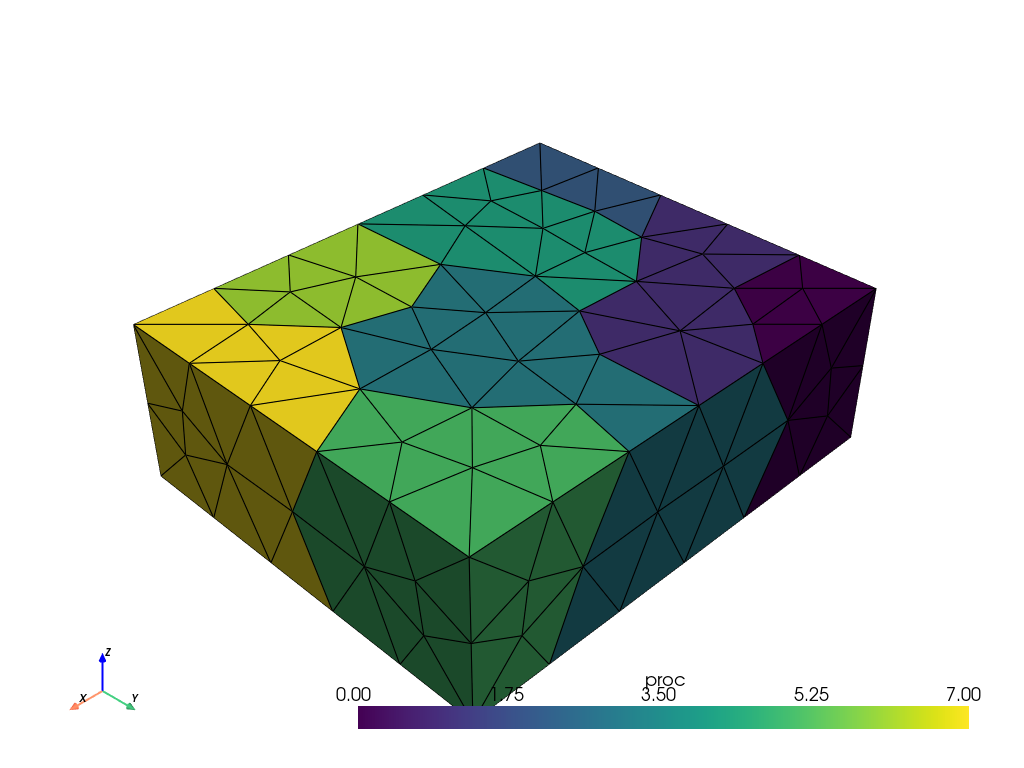

In [12]:
%%px 
grid=util.root_rank(domain)
if domain.comm.rank == 0:
    plt=pv.Plotter()
    plt.add_mesh(grid,**pvopt)
    plt.add_axes()
    plt.show()

In [13]:
%%px
domain.name="plate3D"

### Choose a mesh refinement localization criterion

all domain has to be refined

In [14]:
%%px
def crit(coords,level):
    return coords[0]>-1.

### Choose macro node to enrich
select all nodes

In [15]:
%%px
def enriched(coords):
    return coords[0]>-1.


## Scale Jump construction

In [16]:
%%px
j=core.topDown(domain,enriched,crit,ref)

In [17]:
%%px
fdomain=j.getFineMesh
cdomain=j.getCoarseMesh

[output:0]

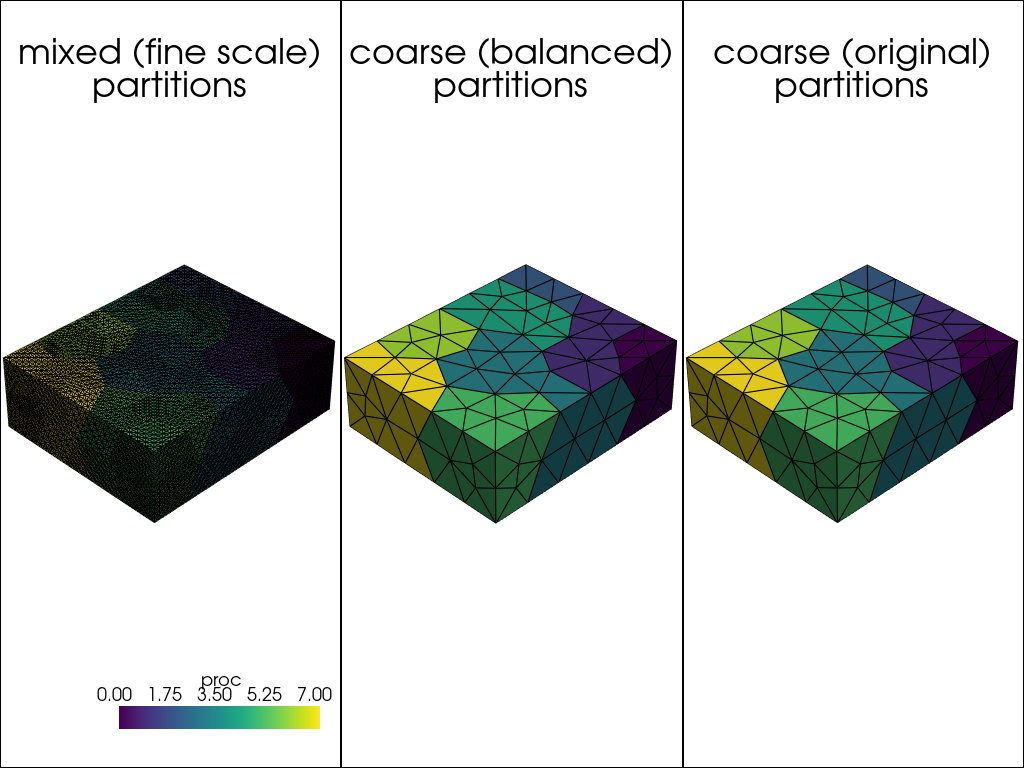

In [18]:
%%px 
gridf=util.root_rank(fdomain)
gridc=util.root_rank(cdomain)
grido=util.root_rank(odomain)
if cdomain.comm.rank == 0:
    plt=pv.Plotter(shape=(1, 3))
    plt.subplot(0, 0)
    plt.add_mesh(gridf,**pvopt)
    plt.add_title("mixed (fine scale)\npartitions",font_size=15)
    plt.subplot(0, 1)
    plt.add_mesh(gridc,**pvopt)
    plt.add_title("coarse (balanced)\npartitions",font_size=15)
    plt.subplot(0, 2)
    plt.add_mesh(grido,**pvopt)
    plt.add_title("coarse (original)\npartitions",font_size=15)
    plt.show()
del gridf,gridc,grido

## Fine scale discretisation

### Space

In [19]:
%%px
space = fem.functionspace(fdomain, fdomain.ufl_domain().ufl_coordinate_element())

### Lamè

In [20]:
%%px
E=36.5e+9
nu=0.2
F=1.e+10
mu=fem.Constant(fdomain,E / (2.0 * (1.0 + nu)))
lmbda = fem.Constant(fdomain,E * nu / ((1.0 + nu) * (1.0 - 2.0 * nu)))
coef1=(nu+1)*(1-2.*nu)*F/E
coef2=(1.-nu)*F

### Exact solution

In [21]:
%%px
def exact_sol(coord):
    x=coef1*(2.*nu*(np.power(coord[1],2)-np.power(coord[2],2))+np.power(coord[0],2)*(L/2-coord[0]/3.))
    y=-4*coef1*nu*coord[0]*coord[1]
    z=4*coef1*nu*coord[0]*coord[2]
    return np.array([x,y,z])


In [22]:
%%px
disp_exact=fem.Function(space,name='disp_exact')
disp_exact.interpolate(exact_sol)

[output:0]

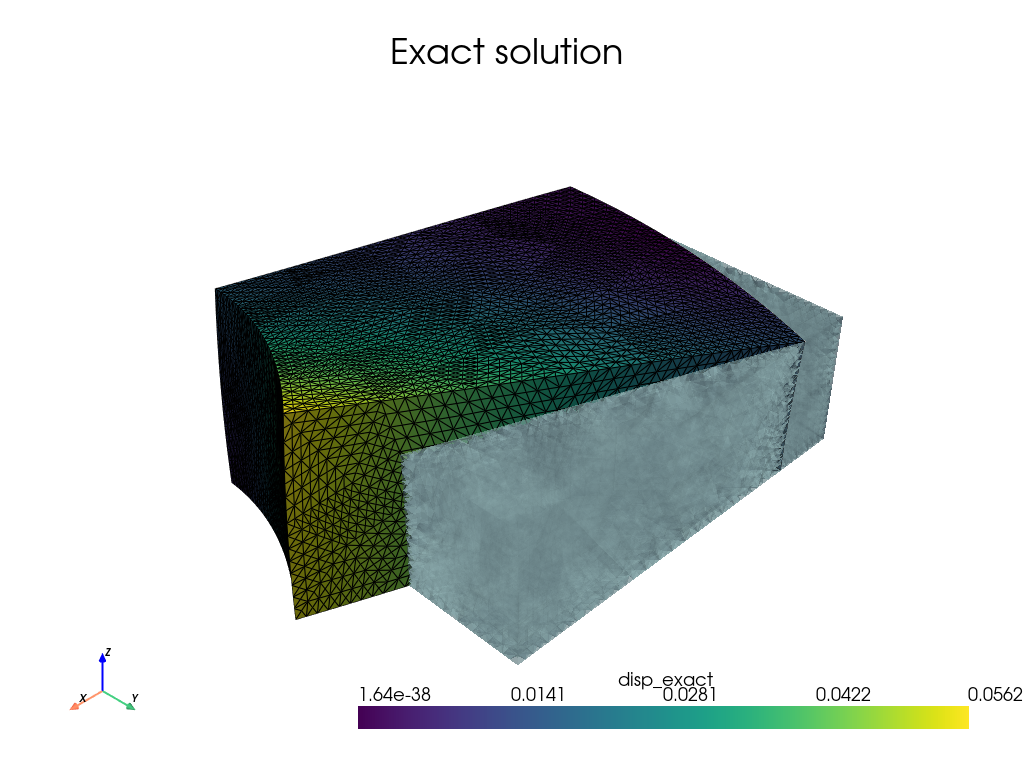

In [23]:
%%px
gridf=util.root_mesh(fdomain)
scale=5.
warpexact=util.root_field(disp_exact,scale)
if cdomain.comm.rank == 0:
    plt=pv.Plotter()
    plt.add_mesh(gridf,opacity=0.5,show_edges=False,)
    plt.add_mesh(warpexact,**pvopt)
    plt.add_title("Exact solution ",font_size=14)
    plt.add_axes()
    plt.show()
del gridf

### Formulation

#### Bilinear form

In [24]:
%%px
u = ufl.TrialFunction(space)
v = ufl.TestFunction(space)

In [25]:
%%px
def eps(v):
    return 0.5*(ufl.grad(v) + ufl.grad(v).T)

In [26]:
%%px
def sigma(strain): 
    return 2.0*mu*strain + lmbda*ufl.tr(strain)*ufl.Identity(dim)

In [27]:
%%px
a_ufl=ufl.inner(sigma(eps(u)), eps(v)) * ufl.dx

#### Volumic load

In [28]:
%%px
metadatav = {"quadrature_rule": "default", "quadrature_degree": 2}
dxx = ufl.measure.Measure("dx", domain = fdomain, metadata = metadatav)
x,y,z = ufl.SpatialCoordinate(fdomain)
fv=ufl.as_vector([coef2*(2*x-L),0,0])
b_ufl=ufl.dot(fv,v)*dxx


#### Surfacic load

Define each face to integrate for surface loading

In [29]:
%%px
bc_face_xz0=mesh.locate_entities(fdomain, 2, lambda x: np.isclose(x[1], 0.))
bc_face_xzB=mesh.locate_entities(fdomain, 2, lambda x: np.isclose(x[1], B))
bc_face_xy0=mesh.locate_entities(fdomain, 2, lambda x: np.isclose(x[2], 0.))
bc_face_xyH=mesh.locate_entities(fdomain, 2, lambda x: np.isclose(x[2], H))
facet_indices=np.hstack((bc_face_xz0,bc_face_xzB,bc_face_xy0,bc_face_xyH)).astype(np.int32)
facet_markers = np.hstack((np.full_like(bc_face_xz0, 1),np.full_like(bc_face_xzB, 1),np.full_like(bc_face_xy0, 2),np.full_like(bc_face_xyH, 2))).astype(np.int32)
sorted_facets = np.argsort(facet_indices)
facet_tag = mesh.meshtags(fdomain, dim, facet_indices[sorted_facets], facet_markers[sorted_facets])
metadatas = {"quadrature_rule": "default", "quadrature_degree": 3}
ds = ufl.Measure("ds", domain=fdomain, subdomain_data=facet_tag,metadata=metadatas) 


Define each formulation based on ufl expression for each surface

In [30]:
%%px
n=ufl.FacetNormal(fdomain)
fsxy=x*F*nu*(L-x+4*(1-2*nu))
fsxz=x*F*nu*(L-x-4*(1-2*nu))
b_ufl+=ufl.inner(fsxz*n,v)*ds(1)
b_ufl+=ufl.inner(fsxy*n,v)*ds(2)
#print(b_ufl)


### Dirichelet

A(0,0,0) corner clamped to block x,y,z translation and $\theta_x$,$\theta_y$,$\theta_z$ rotations

In [31]:
%%px
node_A=mesh.locate_entities(fdomain, 0, lambda x: np.logical_and(np.isclose(x[0], 0.),np.logical_and(np.isclose(x[1], 0.),np.isclose(x[2],0.))))
A_dofs=fem.locate_dofs_topological(space,0,node_A)
bcA=fem.dirichletbc(np.array([0.,0.,0.]),A_dofs,space)

B(L,0,0) node clamped in y,z direction to block $\theta_z$,$\theta_y$

In [32]:
%%px
node_B=mesh.locate_entities(fdomain, 0, lambda x: np.logical_and(np.isclose(x[0], L),np.logical_and(np.isclose(x[1], 0.),np.isclose(x[2],0.))))
By_dofs=fem.locate_dofs_topological(space.sub(1),0,node_B)
bcBy=fem.dirichletbc(0.,By_dofs,space.sub(1))
Bz_dofs=fem.locate_dofs_topological(space.sub(2),0,node_B)
bcBz=fem.dirichletbc(0.,Bz_dofs,space.sub(2))


C(0,B,0) node clamped in z direction to block $\theta_x$

In [33]:
%%px
node_C=mesh.locate_entities(fdomain, 0, lambda x: np.logical_and(np.isclose(x[0], 0.),np.logical_and(np.isclose(x[1], B),np.isclose(x[2],0.))))
C_dofs=fem.locate_dofs_topological(space.sub(2),0,node_C)
bcC=fem.dirichletbc(0.,C_dofs,space.sub(2))

bcs=[bcA,bcBy,bcBz,bcC]

### field

In [34]:
%%px 
disp=fem.Function(space,name='disp_fine')

### Solve with direct resolution

In [35]:
%%px
problem = petsc.LinearProblem(a_ufl, b_ufl,bcs=bcs,petsc_options=petsc_options,petsc_options_prefix="f_")

In [36]:
%%px
disp = problem.solve()

[output:0]

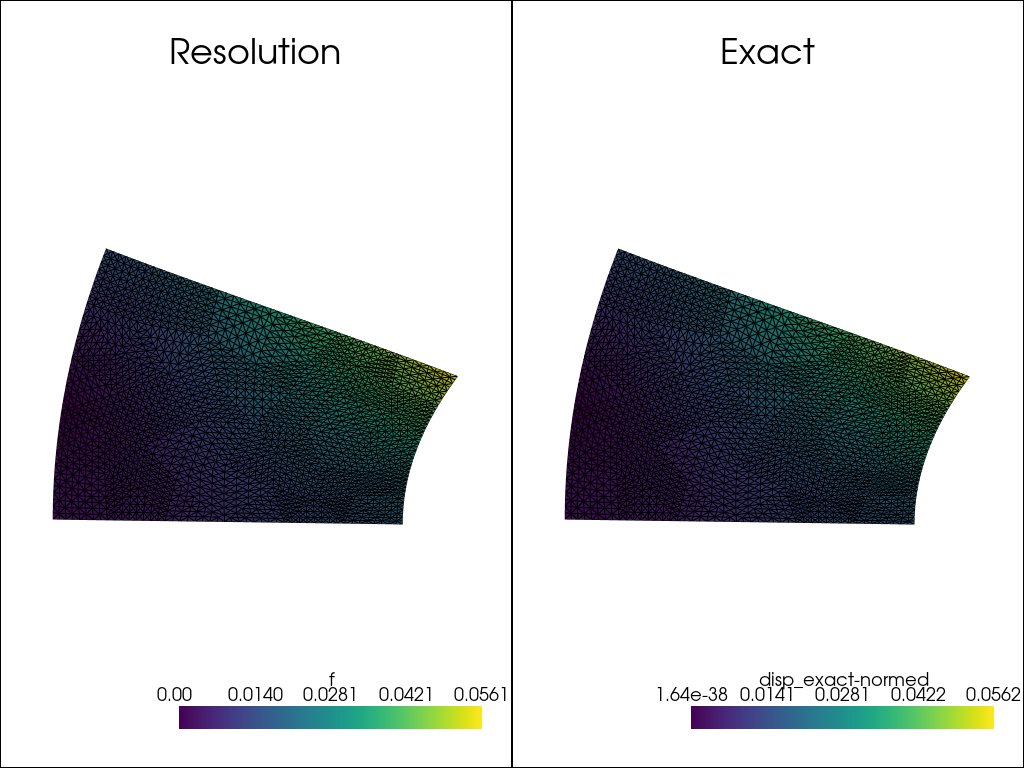

In [37]:
%%px
del problem
warpf=util.root_field(disp,scale)
if cdomain.comm.rank == 0:
    plt=pv.Plotter(shape=(1, 2))
    plt.subplot(0, 0)
    plt.add_title("Resolution",font_size=15)
    plt.add_mesh(warpf,**pvopt)
    plt.camera_position="xy"
    plt.subplot(0, 1)
    plt.add_title("Exact",font_size=15)
    plt.add_mesh(warpexact,**pvopt)
    plt.camera_position="xy"
    plt.show()

## Twoscale approach

In [38]:
%%px
nested_strategy=core.useNest()


In [39]:
%%px --target=0
if nested_strategy:
    print("Use nested strategy")
else:
    print("Use monolithic strategy")

[stdout:0] Use nested strategy


### Enriched space

In [40]:
%%px
if nested_strategy:
    std=fem.functionspace(cdomain, cdomain.ufl_domain().ufl_coordinate_element())
else:
    el_mixed = basix.ufl.mixed_element([cdomain.ufl_domain().ufl_coordinate_element(), cdomain.ufl_domain().ufl_coordinate_element()])
    coarse_enriched_space = fem.functionspace(cdomain, el_mixed)
    std_=coarse_enriched_space.sub(0)
    std, std_to_mix=std_.collapse()
    enr_=coarse_enriched_space.sub(1)
    enr, enr_to_mix=enr_.collapse()
    std_to_mix_np=np.array(std_to_mix[0],dtype=int)

    disp_ce=fem.Function(coarse_enriched_space,name='disp_coarse_enriched')


### Solve coarse non enriched problem (standard part) to init two scale loop

#### Formulation

In [41]:
%%px

muc=fem.Constant(cdomain,E / (2.0 * (1.0 + nu)))
lmbdac = fem.Constant(cdomain,E * nu / ((1.0 + nu) * (1.0 - 2.0 * nu)))
ucs = ufl.TrialFunction(std)
vcs = ufl.TestFunction(std)
def sigmac(strain): 
    return 2.0*muc*strain + lmbdac*ufl.tr(strain)*ufl.Identity(dim)
acs=ufl.inner(sigmac(eps(ucs)), eps(vcs)) * ufl.dx
dxxc = ufl.measure.Measure("dx", domain = cdomain, metadata = metadatav)
xc,_,_ = ufl.SpatialCoordinate(cdomain)
fvc=ufl.as_vector([coef2*(2*xc-L),0,0])
bcst=ufl.dot(fvc,vcs)*dxxc
bc_face_xz0c=mesh.locate_entities(cdomain, 2, lambda x: np.isclose(x[1], 0.))
bc_face_xzBc=mesh.locate_entities(cdomain, 2, lambda x: np.isclose(x[1], B))
bc_face_xy0c=mesh.locate_entities(cdomain, 2, lambda x: np.isclose(x[2], 0.))
bc_face_xyHc=mesh.locate_entities(cdomain, 2, lambda x: np.isclose(x[2], H))
facet_indicesc=np.hstack((bc_face_xz0c,bc_face_xzBc,bc_face_xy0c,bc_face_xyHc)).astype(np.int32)
facet_markersc = np.hstack((np.full_like(bc_face_xz0c, 1),np.full_like(bc_face_xzBc, 1),np.full_like(bc_face_xy0c, 2),np.full_like(bc_face_xyHc, 2))).astype(np.int32)
sorted_facetsc = np.argsort(facet_indicesc)
facet_tagc = mesh.meshtags(cdomain, dim, facet_indicesc[sorted_facetsc], facet_markersc[sorted_facetsc])
dsc = ufl.Measure("ds", domain=cdomain, subdomain_data=facet_tagc,metadata=metadatas) 
nc=ufl.FacetNormal(cdomain)
fsxyc=xc*F*nu*(L-xc+4*(1-2*nu))
fsxzc=xc*F*nu*(L-xc-4*(1-2*nu))
bcst+=ufl.inner(fsxzc*nc,vcs)*dsc(1)
bcst+=ufl.inner(fsxyc*nc,vcs)*dsc(2)


#### Boundary condition

In [42]:
%%px
node_Ac=mesh.locate_entities(cdomain, 0, lambda x: np.logical_and(np.isclose(x[0], 0.),np.logical_and(np.isclose(x[1], 0.),np.isclose(x[2],0.))))
A_dofsc=fem.locate_dofs_topological(std,0,node_Ac)
bcAc=fem.dirichletbc(np.array([0.,0.,0.]),A_dofsc,std)
node_Bc=mesh.locate_entities(cdomain, 0, lambda x: np.logical_and(np.isclose(x[0], L),np.logical_and(np.isclose(x[1], 0.),np.isclose(x[2],0.))))
By_dofsc=fem.locate_dofs_topological(std.sub(1),0,node_Bc)
bcByc=fem.dirichletbc(0.,By_dofsc,std.sub(1))
Bz_dofsc=fem.locate_dofs_topological(std.sub(2),0,node_Bc)
bcBzc=fem.dirichletbc(0.,Bz_dofsc,std.sub(2))
node_Cc=mesh.locate_entities(cdomain, 0, lambda x: np.logical_and(np.isclose(x[0], 0.),np.logical_and(np.isclose(x[1], B),np.isclose(x[2],0.))))
C_dofsc=fem.locate_dofs_topological(std.sub(2),0,node_Cc)
bcCc=fem.dirichletbc(0.,C_dofsc,std.sub(2))

bcscs=[bcAc,bcByc,bcBzc,bcCc]

#### Resolution

In [43]:
%%px
problemcs = petsc.LinearProblem(acs, bcst,bcs=bcscs,petsc_options=petsc_options,petsc_options_prefix="c_")
dispcs = problemcs.solve()

[output:0]

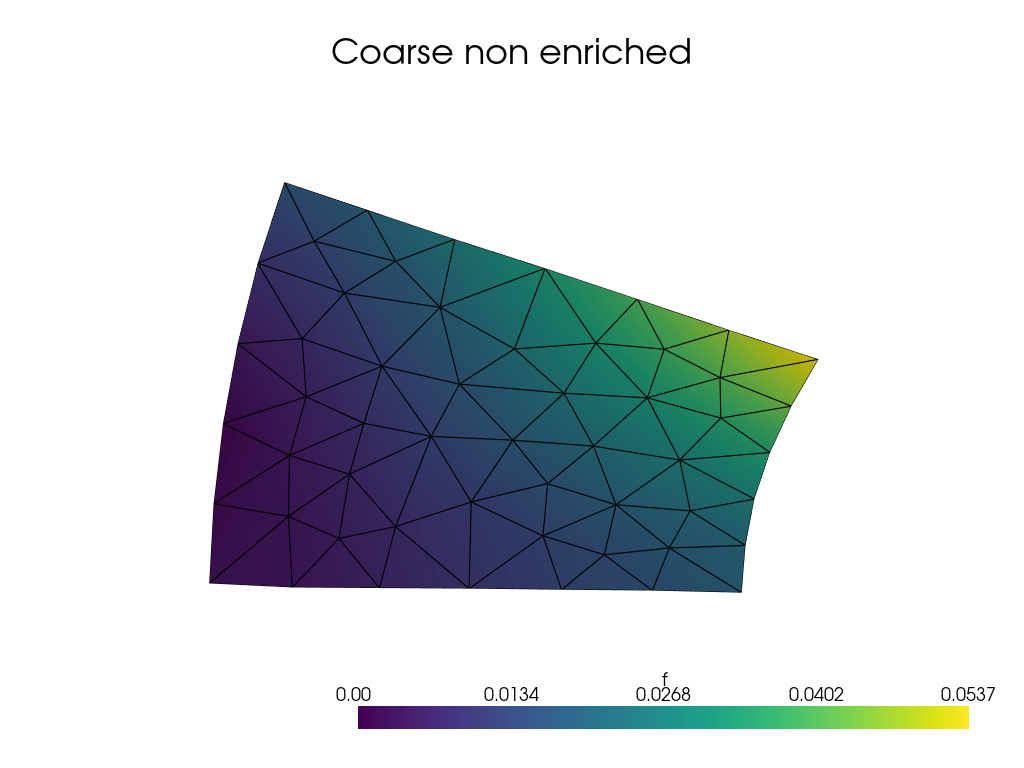

In [44]:
%%px
warpcs=util.root_field(dispcs,scale)
if cdomain.comm.rank == 0:
    plt=pv.Plotter()
    plt.add_mesh(warpcs,**pvopt)
    plt.add_title("Coarse non enriched",font_size=15)
    plt.camera_position="xy"
    plt.show()

#### Store coarse standard in coarse enriched field

In [45]:
%%px 
if nested_strategy:
    disp_ce=dispcs
else:
    disp_ce.x.array[std_to_mix_np]=dispcs.x.array
#print(disp_ce.x.array)

### Twoscale loop

#### Chose an enriched function

In [46]:
%%px
enriched_shift=core.generateEnrichedShiftFunction(disp)

#### resolution with linearBasicLoop (i.e. scale loop resolution)

Dirichlet boundary condition must be defined on mixed space and merged into one Dirichlet BC object for non nested strategy

In [47]:
%%px 
if nested_strategy:
    BC_ce=bcscs
else:
    A_dofsce=fem.locate_dofs_topological(std_,0,node_Ac)
    By_dofsce=fem.locate_dofs_topological(std.sub(1),0,node_Bc)
    By_dofsce=std_to_mix_np[By_dofsce]
    Bz_dofsce=fem.locate_dofs_topological(std.sub(2),0,node_Bc)
    Bz_dofsce=std_to_mix_np[Bz_dofsce]
    C_dofsce=fem.locate_dofs_topological(std.sub(2),0,node_Cc)
    C_dofsce=std_to_mix_np[C_dofsce]
    all_BC_dof=np.concat((A_dofsce,By_dofsce,Bz_dofsce,C_dofsce))
    all_BC_dof.sort()
    all_BC_values=fem.Function(coarse_enriched_space)
    BC_ce=[fem.dirichletbc(all_BC_values,all_BC_dof)]


System are created and TS resolution is done considering Dirichlet BC (i.e. rigide body mode elimination) imposed at patch level:

In [48]:
%%px 
[A,AD,BND,BD]=util.createFineScaleSytems(a_ufl,b_ufl,bcs=bcs)
[dispf, r, nm,it,hr,hrr]=linear.linearBasicLoop(j,space,A,AD,BND,BD,enriched_shift,disp_ce,None,BC_ce,itmax*2,epsr)

#### resolution with init/runLinearBasicLoop (i.e. scale loop resolution)

When Dirichlet BC are only used to block rigide body mode, patches problem do not needs to blocks these dofs. Because at patch level blocking these dofs is meaning less and over constrains the patch. To avoid using these dofs one must use the init/runLinearBasicLoop function where system provided to initLinearBasicLoop is the one without Dirichlet BC eliminated.

In [49]:
%%px 
[dispf2, cm, pm]=linear.initLinearBasicLoop(j,A,BND,space,disp_ce,None,BC_ce)
[r2, it2,hr2,hrr2]=linear.runLinearBasicLoop(dispf2,cm,pm,A,AD,BND,BD,enriched_shift,disp_ce,None,itmax,epsr)

In [50]:
print(f"Convergence to {view['epsr'][0]} obtained after  {len(view['hr2'][0])-1} TS iterations with relative convergence {view['hr2'][0][len(view['hr2'][0])-1]}")

Convergence to 1e-07 obtained after  20 TS iterations with relative convergence 6.409758465181817e-08


#### resolution with init/runLinearBasicLoop with Eimp

In [51]:
%%px 
if nested_strategy:
    [dispf3, cm3, pm3]=linear.initLinearBasicLoop(j,A,BND,space,disp_ce,None,BC_ce)
    [r3, it3,hr3,hrr3]=linear.runLinearBasicLoopEImp(dispf3,cm3,pm3,A,AD,BND,BD,enriched_shift,disp_ce,None,5,itmax,epsr)

In [52]:
if view['nested_strategy'][0]:
    print(f"Convergence to {view['epsr'][0]} obtained after  {len(view['hr3'][0])-1} TS iterations with relative convergence {view['hr3'][0][len(view['hr3'][0])-1]}")

Convergence to 1e-07 obtained after  22 TS iterations with relative convergence 7.379889331971147e-08


## Results
Solutions with direct solver and TS solver are plotted bellow with theire differences

[output:0]

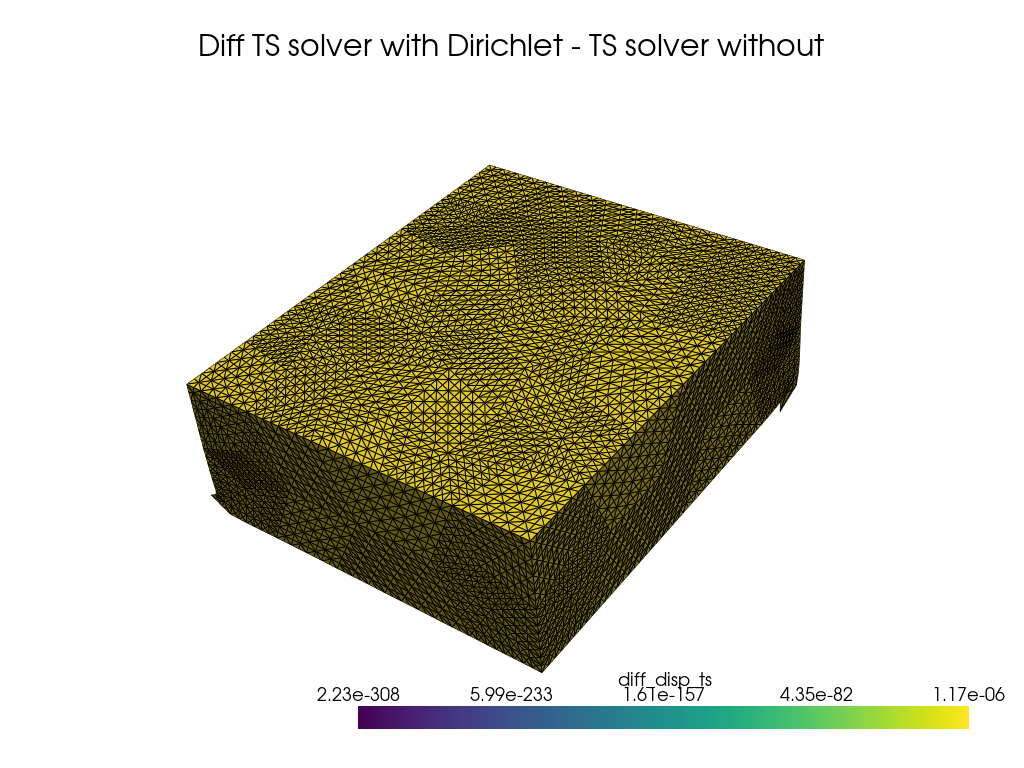

[output:0]

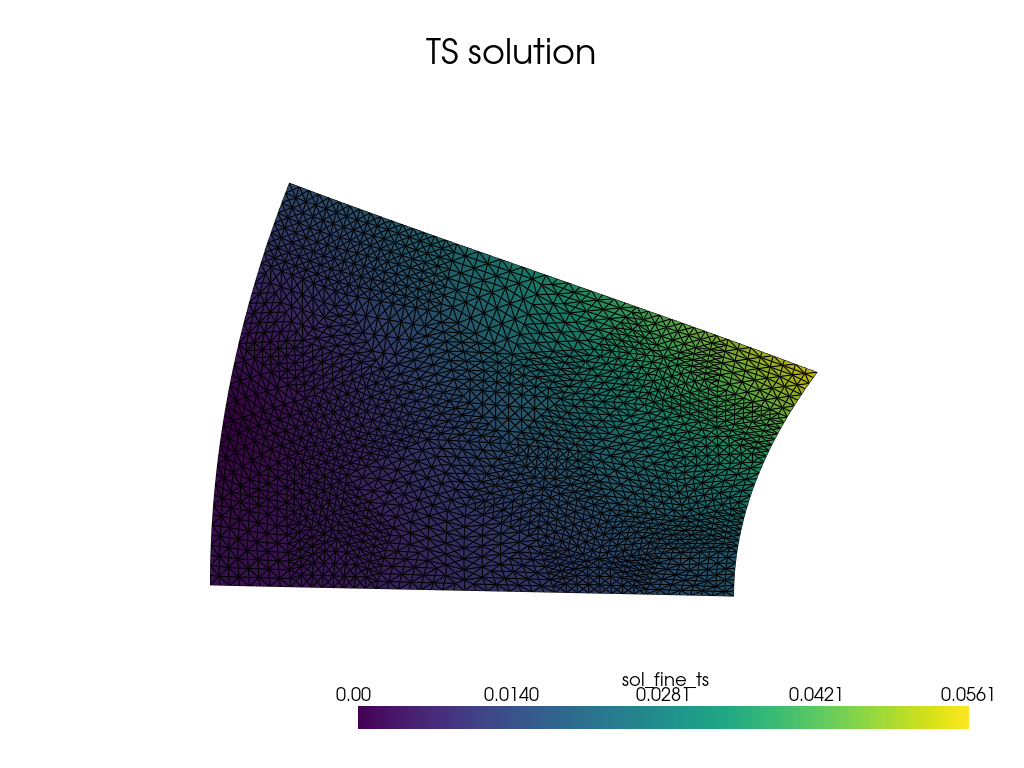

[output:0]

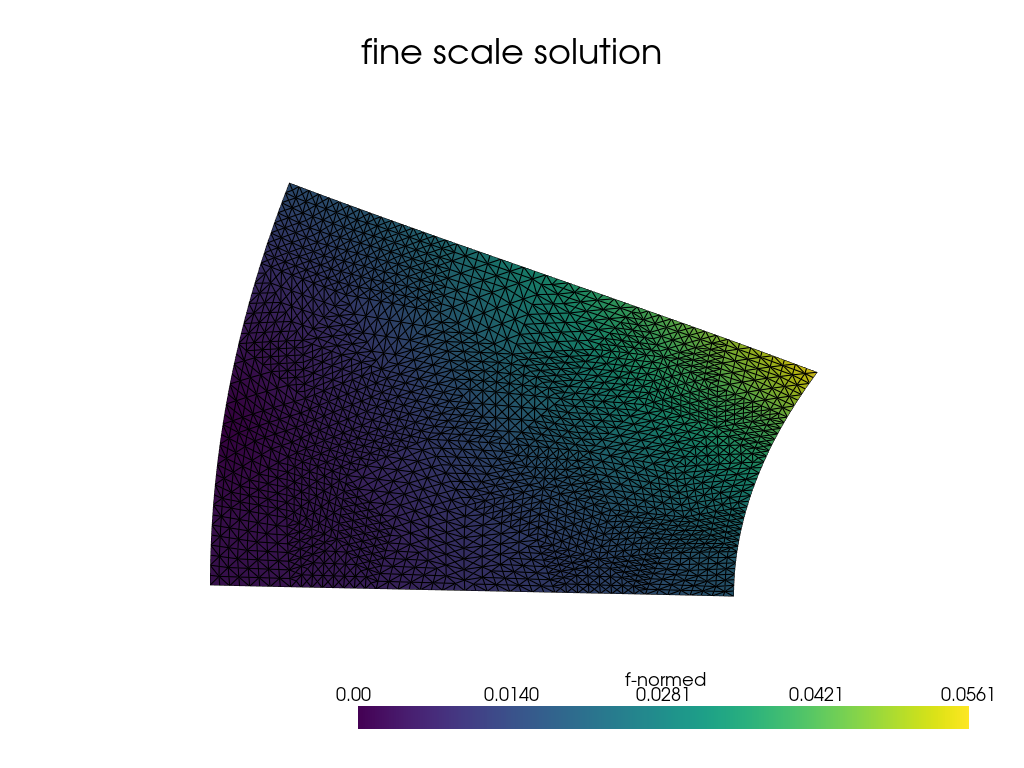

[output:0]

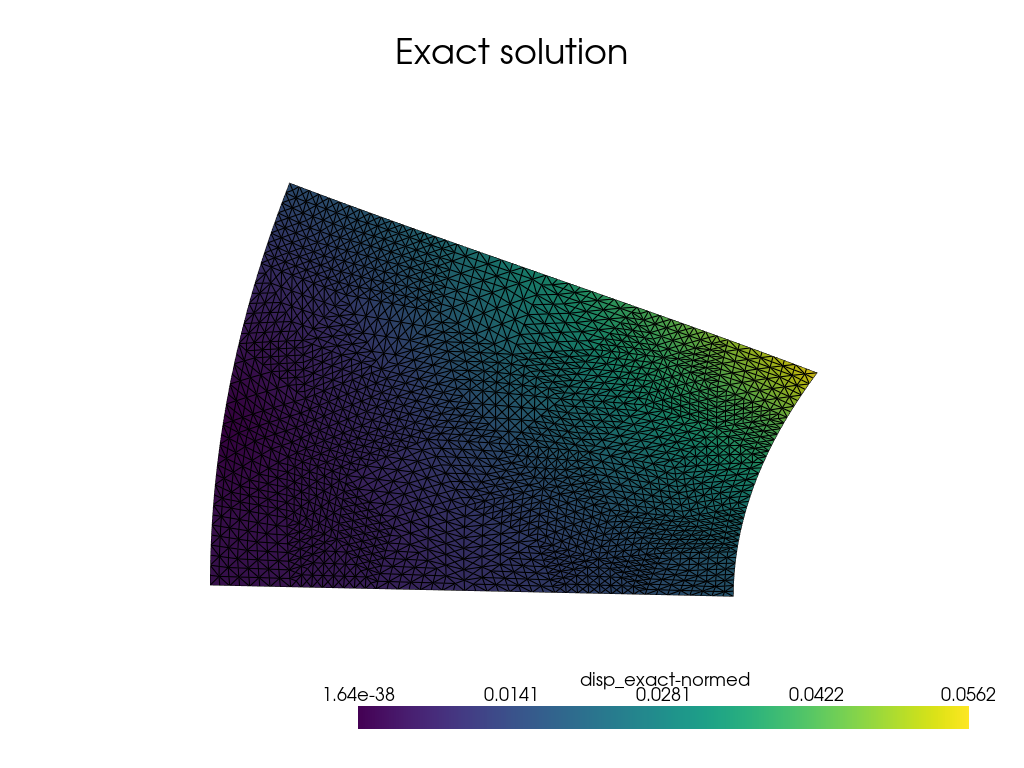

[output:0]

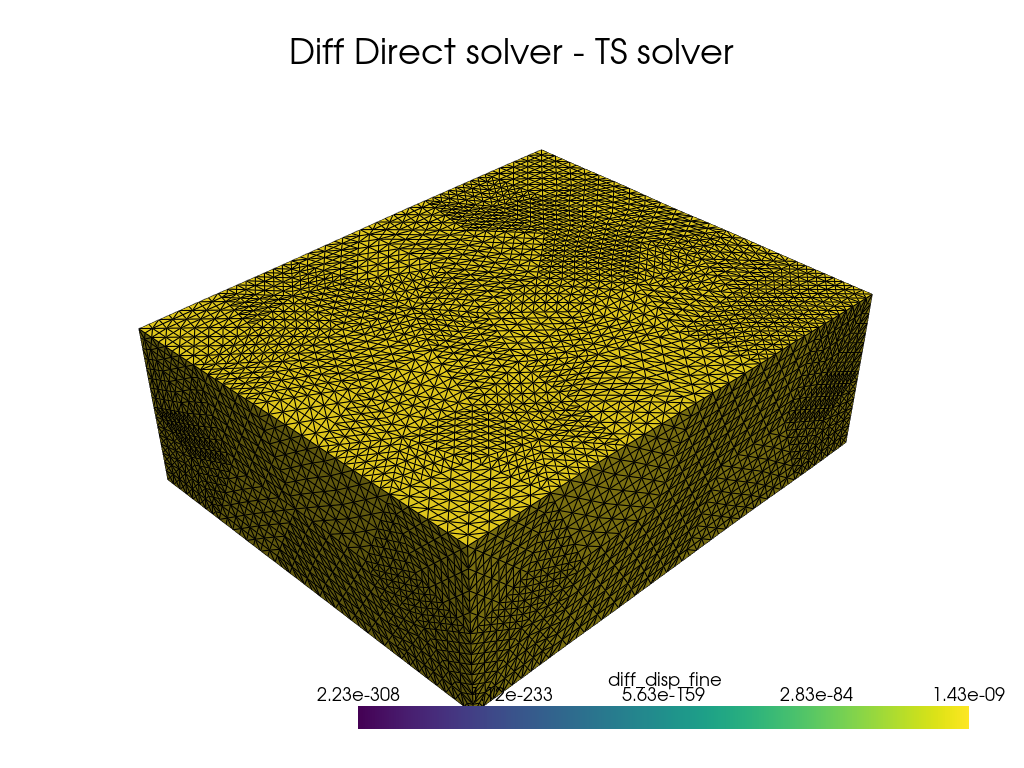

[output:0]

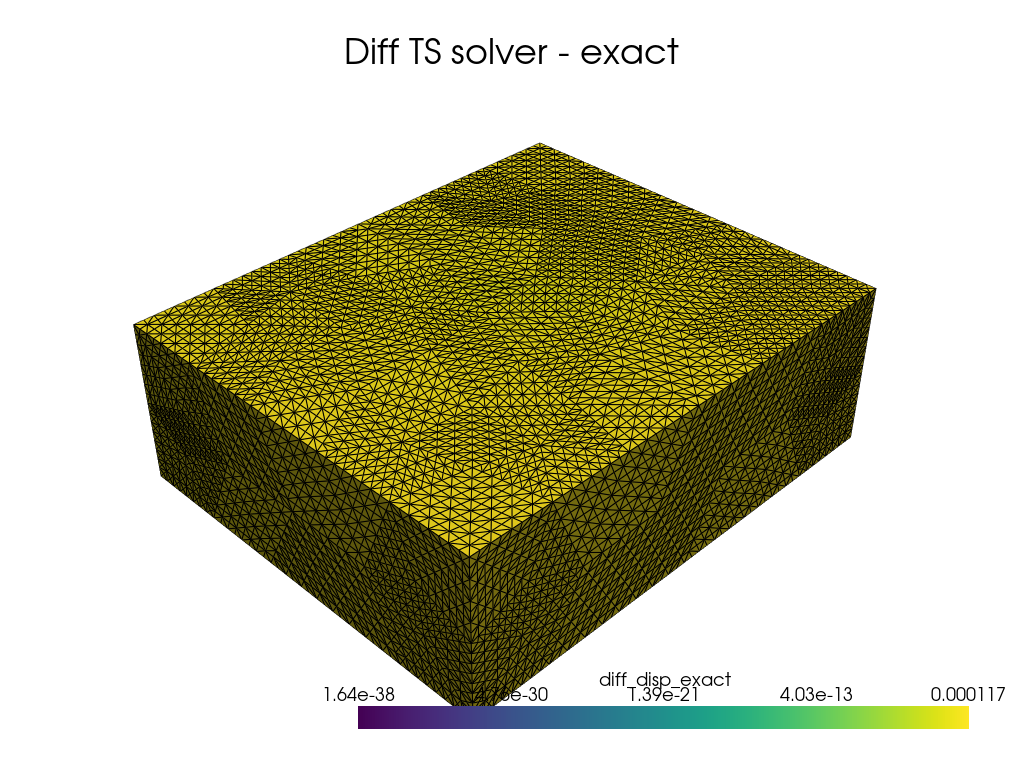

In [53]:
%%px
warpts=util.root_field(dispf,scale)
warpts2=util.root_field(dispf2,scale)
#warpfm=util.root_field(dispw,100)
ddispt=fem.Function(space,name='diff_disp_ts')
ddispt.x.array[:]=dispf.x.array-dispf2.x.array
warpdst=util.root_field(ddispt,1.e5,1)
if cdomain.comm.rank == 0:
    plt=pv.Plotter()
    plt.add_mesh(warpdst,show_edges=True, show_scalar_bar=True, log_scale=True, copy_mesh=True)
    plt.add_title("Diff TS solver with Dirichlet - TS solver without",font_size=13)
    #plt.camera_position="xy"
    plt.show()
if cdomain.comm.rank == 0:
    plt=pv.Plotter()
    plt.add_mesh(warpts,**pvopt)
    plt.add_title("TS solution",font_size=14)
    plt.camera_position="xy"
    plt.show()
if cdomain.comm.rank == 0:
    plt=pv.Plotter()
    plt.add_mesh(warpf,**pvopt)
    plt.add_title("fine scale solution",font_size=14)
    plt.camera_position="xy"
    plt.show()
if cdomain.comm.rank == 0:
    plt=pv.Plotter()
    plt.add_mesh(warpexact,**pvopt)
    plt.add_title("Exact solution",font_size=14)
    plt.camera_position="xy"
    plt.show()
ddisp=fem.Function(space,name='diff_disp_fine')
ddisp.x.array[:]=disp.x.array-dispf2.x.array
warpds=util.root_field(ddisp,1.e7,1)
if cdomain.comm.rank == 0:
    plt=pv.Plotter()
    plt.add_mesh(warpds,show_edges=True, show_scalar_bar=True, log_scale=True, copy_mesh=True)
    plt.add_title("Diff Direct solver - TS solver",font_size=14)
    #plt.camera_position="xy"
    plt.show()
ddispe=fem.Function(space,name='diff_disp_exact')
ddispe.x.array[:]=dispf2.x.array-disp_exact.x.array
warpdse=util.root_field(ddispe,1.e0,1)
if cdomain.comm.rank == 0:
    plt=pv.Plotter()
    plt.add_mesh(warpdse,show_edges=True, show_scalar_bar=True, log_scale=True, copy_mesh=True)
    plt.add_title("Diff TS solver - exact",font_size=14)
    #plt.camera_position="xy"
    plt.show()


The difference in between imposing or not Dirichlet BC at patch level may looks almost "null" as it can be seen above. But depending on scale jump TS can  not converge with Dirichlet imposed at patch level. In all case the way to reach this solution is not the same as it can be seen below with residual evolution:

Text(0, 0.5, '$norm(AD.S_{ts_i}-BD)/norm(BD)$')

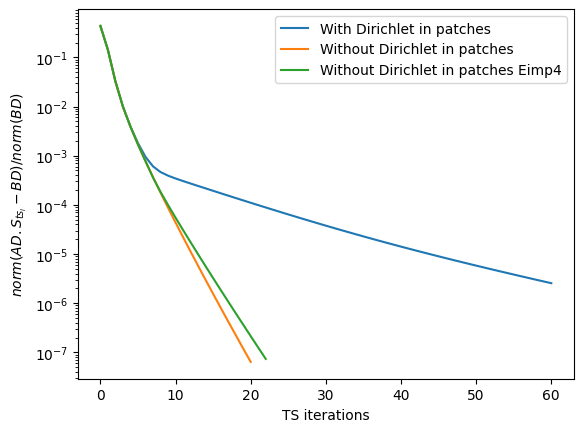

In [54]:
import matplotlib.pyplot as mplt
mplt.plot(view['hr'][0],label='With Dirichlet in patches')
mplt.plot(view['hr2'][0],label='Without Dirichlet in patches')
if view['nested_strategy'][0]:
    mplt.plot(view['hr3'][0],label='Without Dirichlet in patches Eimp4')
mplt.legend()
mplt.yscale('log')
mplt.xlabel('TS iterations')
mplt.ylabel('$norm(AD.S_{ts_i}-BD)/norm(BD)$')

In [55]:
%%px
dispf2.x.array[:]=0.
deltatd=fem.Function(space,name='diff_ts_direct')
deltate=fem.Function(space,name='diff_ts_exact')
deltade=fem.Function(space,name='diff_direct_exact')
dxtd=deltatd.x.petsc_vec
dxte=deltate.x.petsc_vec
dxde=deltade.x.petsc_vec

xf=dispf2.x.petsc_vec
xe=disp_exact.x.petsc_vec
cm.projectStdCoarse(disp_ce,dispf2)
nb=BD.norm()
r=linear.residual(AD,BD,xf,nb)
hr=[r]
deltatd.x.array[:]=dispf2.x.array-disp.x.array
deltate.x.array[:]=dispf2.x.array-disp_exact.x.array
deltade.x.array[:]=disp.x.array-disp_exact.x.array
R=BD.duplicate()
A.mult(xe,R)
ne=R.norm()
A.mult(dxtd,R)
hrtd=[R.norm()/ne]
A.mult(dxte,R)
hrte=[R.norm()/ne]
A.mult(dxde,R)
hrde=[R.norm()/ne]
i=0
while (i<itmax and r>epsr):
    pm.solveProblems(dispf2)
    cm.resetCoarseToStd()
    cm.updateEnrichedOperator(pm,enriched_shift)
    cm.updateEnrichCoarse(A,BND)
    cm.solve(dispf2)
    r=linear.residual(AD,BD,xf,nb)
    hr.append(r)
    deltatd.x.array[:]=dispf2.x.array-disp.x.array
    deltate.x.array[:]=dispf2.x.array-disp_exact.x.array
    A.mult(dxtd,R)
    hrtd.append(R.norm()/ne)
    A.mult(dxte,R)
    hrte.append(R.norm()/ne)
    hrde.append(hrde[0])
    i=i+1
 
#print(hr,hrtd,hrte,hrde)



The following criteria have been also computed manually:
* relative difference TS-direct $\frac{|AD.(S_{ts_i}-S_{direct})|}{|AD.S_{exact}|}$
* relative difference TS-exact $\frac{|AD.(S_{ts_i}-S_{exact})|}{|AD.S_{exact}|}$
* relative difference direct-exact $\frac{|AD.(S_{direct}-S_{exact})|}{|AD.S_{exact}|}=cst$

In [56]:
#exlibris L3 from L0
exlibris_ts_exact=[ 3.173304e-02 , 1.801991e-02 , 1.641929e-02 , 1.620244e-02 , 1.616513e-02 , 1.615775e-02 , 1.615617e-02 , 1.615580e-02 , 1.615572e-02 , 1.615570e-02 , 1.615569e-02 , 1.615569e-02 , 1.615569e-02 , 1.615569e-02 , 1.615569e-02 , 1.615569e-02 , 1.615569e-02 , 1.615569e-02 , 1.615569e-02 , 1.615569e-02]
exlibris_residualb=[ 1.,1.174182e-01 , 2.800869e-02 , 9.017054e-03 , 3.589742e-03 , 1.577022e-03 , 7.257255e-04 , 3.450678e-04 , 1.676290e-04 , 8.278346e-05 , 4.139276e-05 , 2.090612e-05 , 1.064780e-05 , 5.462778e-06 , 2.821021e-06 , 1.465579e-06 , 7.656871e-07 , 4.021557e-07 , 2.122847e-07 , 1.125929e-07 , 5.998709e-08 ]
exlibris_ts_direct=[ 1., 2.731619e-02 , 7.982952e-03 , 2.930684e-03 , 1.230108e-03 , 5.523760e-04 , 2.581820e-04 , 1.240555e-04 , 6.081437e-05 , 3.027260e-05 , 1.525328e-05 , 7.762980e-06 , 3.984850e-06 , 2.060956e-06 , 1.073177e-06 , 5.622979e-07 , 2.963093e-07 , 1.569728e-07 , 8.356747e-08 , 4.469140e-08 , 2.400100e-08 ]


Text(0, 0.5, 'Criterion')

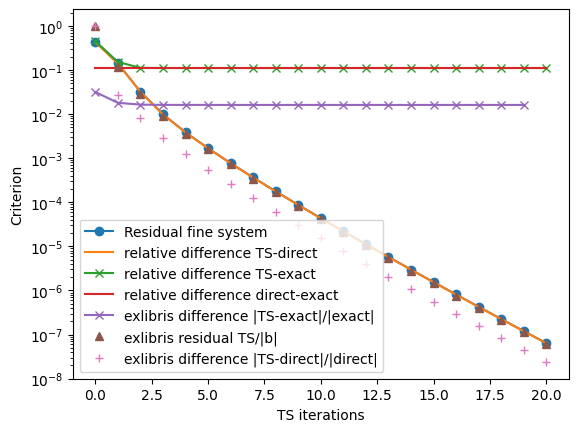

In [57]:
mplt.plot(view['hr2'][0],'o-',label='Residual fine system')
mplt.plot(view['hrtd'][0],label='relative difference TS-direct')
mplt.plot(view['hrte'][0],'x-',label='relative difference TS-exact')
mplt.plot(view['hrde'][0],label='relative difference direct-exact')
mplt.plot(exlibris_ts_exact,'x-',label='exlibris difference |TS-exact|/|exact|')
mplt.plot(exlibris_residualb,'^',label='exlibris residual TS/|b|')
mplt.plot(exlibris_ts_direct,'+',label='exlibris difference |TS-direct|/|direct|')
mplt.legend()
mplt.yscale('log')
mplt.xlabel('TS iterations')
mplt.ylabel('Criterion')

In [58]:
%%px
if (show_petsc_log):
    petsc4py.PETSc.Log.view()